# STRUM Dataset Understanding

## Objective

This notebook explores the STRUM dataset and answers:

- How is the dataset organized?
- What files are available?
- What metadata is provided?
- What is the image format?
- What is the mask format?
- What bands are available?
- What information is needed before preprocessing?

In [7]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import rasterio
from rasterio.plot import show

from PIL import Image

## Define Dataset Paths

Set paths for STRUM dataset components.

In [42]:
ROOT = Path("../dataset/STRUM")

S1_META = ROOT / "Sentinel1_metadata.csv"
S2_META = ROOT / "Sentinel2_metadata.csv"

STRUM_DATASET = ROOT / "Dataset" / "Dataset"

S1_PATH = STRUM_DATASET / "Sentinel1" / "S1"
S1_MASK_PATH = STRUM_DATASET / "Sentinel1" / "Floodmaps"

S2_PATH = STRUM_DATASET / "Sentinel2" / "S2"
S2_MASK_PATH = STRUM_DATASET / "Sentinel2" / "Floodmaps"

In [41]:
from pathlib import Path

ROOT = Path("../dataset/STRUM")

print("ROOT exists:", ROOT.exists())
print()

for item in ROOT.iterdir():
    print(item.name)

ROOT exists: True

Dataset
Sentinel1_metadata.csv
Sentinel2_metadata.csv


## Verify Dataset Structure

In [43]:
for path in [
    ROOT,
    STRUM_DATASET,
    S1_PATH,
    S2_PATH,
    S1_MASK_PATH,
    S2_MASK_PATH
]:
    print(path)
    print("Exists:", path.exists())
    print("-"*50)

..\dataset\STRUM
Exists: True
--------------------------------------------------
..\dataset\STRUM\Dataset\Dataset
Exists: True
--------------------------------------------------
..\dataset\STRUM\Dataset\Dataset\Sentinel1\S1
Exists: True
--------------------------------------------------
..\dataset\STRUM\Dataset\Dataset\Sentinel2\S2
Exists: True
--------------------------------------------------
..\dataset\STRUM\Dataset\Dataset\Sentinel1\Floodmaps
Exists: True
--------------------------------------------------
..\dataset\STRUM\Dataset\Dataset\Sentinel2\Floodmaps
Exists: True
--------------------------------------------------


## Inspect Metadata Files

Understanding metadata is important because it may contain:

- sample information
- acquisition dates
- flood events
- train/validation/test split

In [48]:
s1_meta = pd.read_csv(S1_META)
s2_meta = pd.read_csv(S2_META)

print("Sentinel-1 Metadata Shape:", s1_meta.shape)
print("Sentinel-2 Metadata Shape:", s2_meta.shape)

Sentinel-1 Metadata Shape: (21602, 10)
Sentinel-2 Metadata Shape: (2675, 10)


In [49]:
display(s1_meta.head())
display(s2_meta.head())

,Unnamed: 0,ems_code,aoi_code,floodmap_id,event_type,country,tile_id,epsg_code,floodmap_date,sentinel_date
0,0,EMSR260,02VIADANA,EMSR260_02VIADANA_DEL_MONIT01_v2,Riverine flood,Italy,EMSR260_02VIADANA_2_1_2_2.tif,32632,2017-12-14 05:10:00,2017-12-12 05:27:24
1,1,EMSR260,02VIADANA,EMSR260_02VIADANA_DEL_MONIT01_v2,Riverine flood,Italy,EMSR260_02VIADANA_2_2_2_1.tif,32632,2017-12-14 05:10:00,2017-12-12 05:27:24
2,2,EMSR260,02VIADANA,EMSR260_02VIADANA_DEL_MONIT01_v2,Riverine flood,Italy,EMSR260_02VIADANA_2_2_2_2.tif,32632,2017-12-14 05:10:00,2017-12-12 05:27:24
3,3,EMSR260,02VIADANA,EMSR260_02VIADANA_DEL_MONIT01_v2,Riverine flood,Italy,EMSR260_02VIADANA_3_2_1_2.tif,32632,2017-12-14 05:10:00,2017-12-12 05:27:24
4,4,EMSR260,09RUBIERA,EMSR260_09RUBIERA_DEL_MONIT01_v1,Riverine flood,Italy,EMSR260_09RUBIERA_1_1_2_2.tif,32632,2017-12-13 05:18:00,2017-12-12 05:27:24


,Unnamed: 0,ems_code,aoi_code,floodmap_id,event_type,country,tile_id,epsg_code,floodmap_date,sentinel_timestamp
0,0,EMSR279,03ALFARO,EMSR279_03ALFARO_DEL_v1,Riverine flood,Spain,EMSR279_03ALFARO_17_16_1_1.tif,32630,2018-04-14 20:03:00,2018-04-14 10:56:51
1,1,EMSR279,03ALFARO,EMSR279_03ALFARO_DEL_v1,Riverine flood,Spain,EMSR279_03ALFARO_17_16_2_1.tif,32630,2018-04-14 20:03:00,2018-04-14 10:56:51
2,2,EMSR279,03ALFARO,EMSR279_03ALFARO_DEL_v1,Riverine flood,Spain,EMSR279_03ALFARO_17_16_2_2.tif,32630,2018-04-14 20:03:00,2018-04-14 10:56:51
3,3,EMSR279,03ALFARO,EMSR279_03ALFARO_DEL_v1,Riverine flood,Spain,EMSR279_03ALFARO_19_18_1_2.tif,32630,2018-04-14 20:03:00,2018-04-14 10:56:51
4,4,EMSR279,03ALFARO,EMSR279_03ALFARO_DEL_v1,Riverine flood,Spain,EMSR279_03ALFARO_19_18_2_2.tif,32630,2018-04-14 20:03:00,2018-04-14 10:56:51


## Explore Sentinel-2 Files

In [52]:
s2_files = sorted(list(S2_PATH.glob("*")))

print("Number of Sentinel-2 Files:", len(s2_files))
print()

for f in s2_files[:10]:
    print(f.name)

Number of Sentinel-2 Files: 2675

EMSR279_03ALFARO_17_16_1_1.tif
EMSR279_03ALFARO_17_16_2_1.tif
EMSR279_03ALFARO_17_16_2_2.tif
EMSR279_03ALFARO_19_18_1_2.tif
EMSR279_03ALFARO_19_18_2_2.tif
EMSR279_03ALFARO_19_19_1_1.tif
EMSR279_03ALFARO_19_19_1_2.tif
EMSR279_03ALFARO_19_19_2_1.tif
EMSR279_03ALFARO_19_19_2_2.tif
EMSR279_04TUDELA_01_03_2_2.tif


## Inspect File Extensions

In [53]:
extensions = {}

for f in s2_files:
    ext = f.suffix

    if ext not in extensions:
        extensions[ext] = 0

    extensions[ext] += 1

extensions

{'.tif': 2675}

## Load One Sentinel-2 Sample

In [54]:
sample_file = s2_files[0]

print(sample_file)

..\dataset\STRUM\Dataset\Dataset\Sentinel2\S2\EMSR279_03ALFARO_17_16_1_1.tif


In [55]:
with rasterio.open(sample_file) as src:

    print("Width :", src.width)
    print("Height:", src.height)
    print("Bands :", src.count)

    image = src.read()

print("Image Shape:", image.shape)

Width : 128
Height: 128
Bands : 9
Image Shape: (9, 128, 128)


## Band Statistics

In [56]:
print("Shape:", image.shape)

for band in range(image.shape[0]):
    
    print(
        f"Band {band+1}:",
        "Min =", image[band].min(),
        "Max =", image[band].max()
    )

Shape: (9, 128, 128)
Band 1: Min = -0.2708333333333333 Max = 1.015
Band 2: Min = -0.14666666666666667 Max = 1.0433333333333332
Band 3: Min = -0.1925 Max = 1.4225
Band 4: Min = 0.08345443725585938 Max = 1.7027541097005208
Band 5: Min = -0.12702383677164714 Max = 3.618239339192708
Band 6: Min = -0.08409177144368489 Max = 4.405695393880208
Band 7: Min = -0.1275 Max = 4.525833333333333
Band 8: Min = -0.422664680480957 Max = 2.907442626953125
Band 9: Min = -0.4630564117431641 Max = 2.0444535319010417


## Visualize Individual Bands

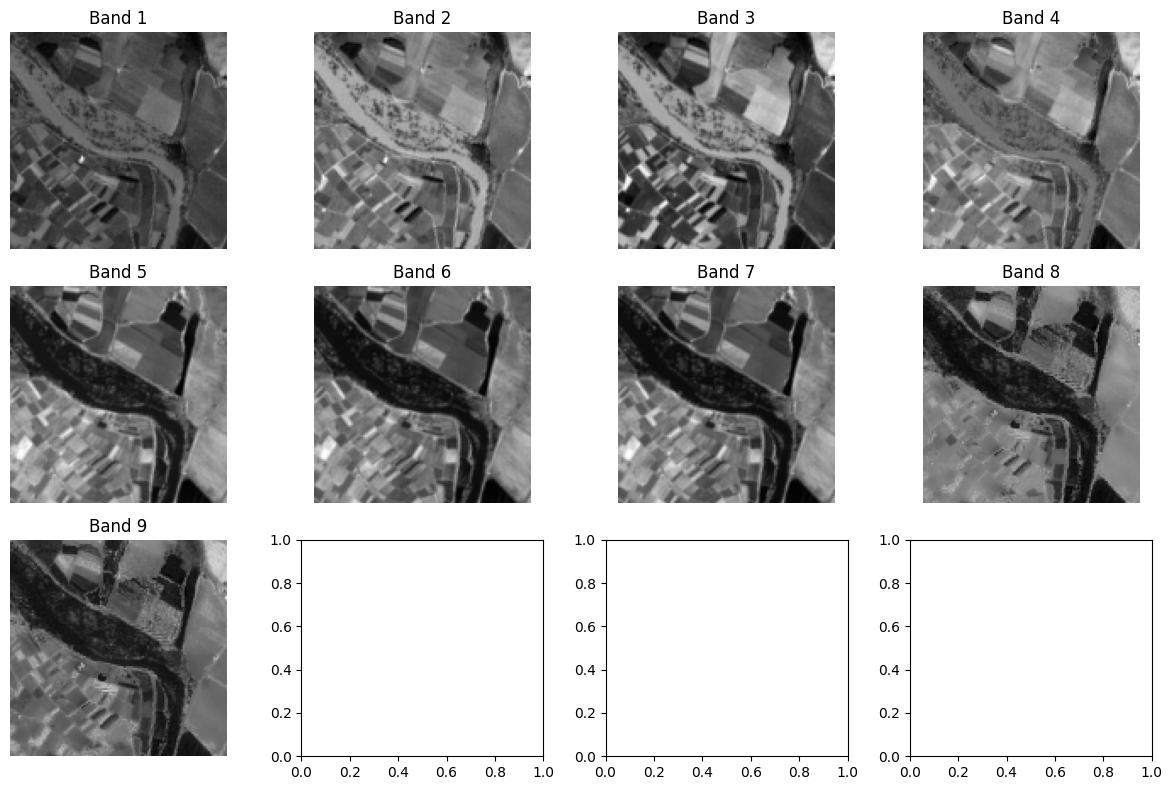

In [57]:
n_bands = min(image.shape[0], 12)

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

axes = axes.flatten()

for i in range(n_bands):
    
    axes[i].imshow(image[i], cmap="gray")
    axes[i].set_title(f"Band {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Explore Flood Masks

In [58]:
mask_files = sorted(list(S2_MASK_PATH.glob("*")))

print("Number of Masks:", len(mask_files))
print()

for f in mask_files[:5]:
    print(f.name)

Number of Masks: 2675

EMSR279_03ALFARO_17_16_1_1.tif
EMSR279_03ALFARO_17_16_2_1.tif
EMSR279_03ALFARO_17_16_2_2.tif
EMSR279_03ALFARO_19_18_1_2.tif
EMSR279_03ALFARO_19_18_2_2.tif


In [59]:
sample_mask = mask_files[0]

print(sample_mask)

..\dataset\STRUM\Dataset\Dataset\Sentinel2\Floodmaps\EMSR279_03ALFARO_17_16_1_1.tif


In [60]:
with rasterio.open(sample_mask) as src:

    mask = src.read(1)

print("Mask Shape:", mask.shape)

Mask Shape: (128, 128)


In [61]:
np.unique(mask)

array([0, 1, 2], dtype=int32)

## Flood Mask Statistics

In [62]:
unique, counts = np.unique(mask, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

Class 0: 13675
Class 1: 912
Class 2: 1797


In [63]:
total_pixels = mask.size

for u, c in zip(unique, counts):
    
    percentage = 100 * c / total_pixels

    print(
        f"Class {u}: {percentage:.2f}%"
    )

Class 0: 83.47%
Class 1: 5.57%
Class 2: 10.97%


## RGB Visualization

Later we will use:

- B04 (Red)
- B03 (Green)
- B02 (Blue)

This cell helps identify the correct band order.

In [64]:
print("Image Shape:", image.shape)

Image Shape: (9, 128, 128)


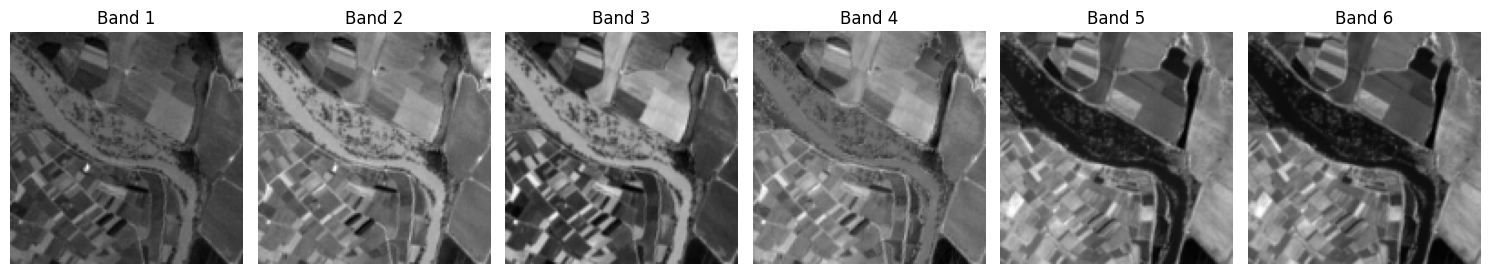

In [65]:
# Temporary band visualization

fig, ax = plt.subplots(
    1,
    min(image.shape[0], 6),
    figsize=(15,5)
)

for i in range(min(image.shape[0],6)):
    
    ax[i].imshow(image[i], cmap="gray")
    ax[i].set_title(f"Band {i+1}")
    ax[i].axis("off")

plt.tight_layout()
plt.show()

In [87]:
from pathlib import Path

s2_files = sorted(list(S2_PATH.glob("*")))

print("Total Files:", len(s2_files))
print("\nSample File:")
print(s2_files[0])

Total Files: 2675

Sample File:
..\dataset\STRUM\Dataset\Dataset\Sentinel2\S2\EMSR279_03ALFARO_17_16_1_1.tif


In [88]:
import rasterio

sample_file = s2_files[0]

with rasterio.open(sample_file) as src:

    image = src.read()

print("Image Shape:", image.shape)

Image Shape: (9, 128, 128)


In [86]:
with rasterio.open(sample_file) as src:

    print("Band Count:", src.count)

    print("\nBand Descriptions:")
    print(src.descriptions)

Band Count: 9

Band Descriptions:
(None, None, None, None, None, None, None, None, None)


In [89]:
print(s2_files[0])

..\dataset\STRUM\Dataset\Dataset\Sentinel2\S2\EMSR279_03ALFARO_17_16_1_1.tif


In [90]:
print(image.shape)

(9, 128, 128)


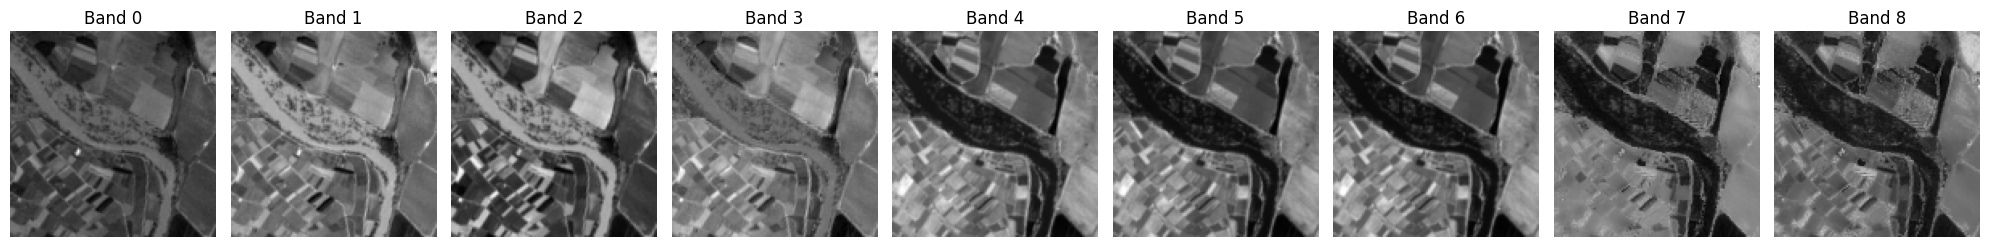

In [93]:
import matplotlib.pyplot as plt
import rasterio

sample_file = s2_files[0]

with rasterio.open(sample_file) as src:
    image = src.read()

fig, axes = plt.subplots(1, 9, figsize=(20,4))

for i in range(9):

    axes[i].imshow(image[i], cmap="gray")
    axes[i].set_title(f"Band {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [94]:
R = image[2]
G = image[1]
B = image[0]

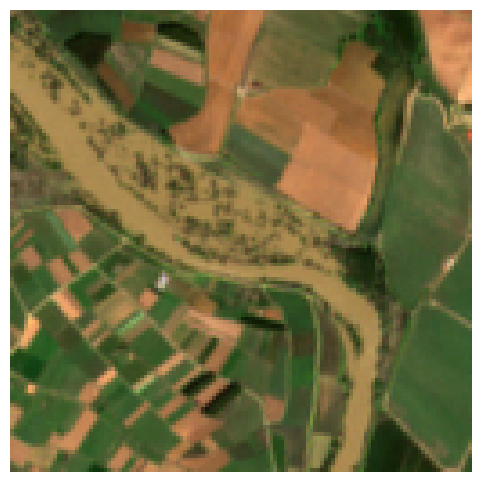

In [95]:
rgb = np.stack(
    [
        image[2],
        image[1],
        image[0]
    ],
    axis=-1
)

rgb = rgb.astype(np.float32)

rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.axis("off")
plt.show()

In [96]:
RGB_INDICES = {
    "red": 2,
    "green": 1,
    "blue": 0
}

In [97]:
mask_files = sorted(list(S2_MASK_PATH.glob("*")))

with rasterio.open(mask_files[0]) as src:
    mask = src.read(1)

print(np.unique(mask))

[0 1 2]


## SEN12-FLOOD Dataset Understanding

### Objective

Inspect the SEN12-FLOOD dataset structure and determine:

- Folder organization
- Available files
- Presence of Sentinel-1 imagery
- Presence of Sentinel-2 imagery
- Presence of masks
- Image formats
- Image dimensions
- Number of bands

This information will be used later for cross-dataset inference.

In [66]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio

In [67]:
SEN12_PATH = Path("../dataset/SEN12/raw/SEN12FLOOD")

print(SEN12_PATH.exists())
print(SEN12_PATH)

True
..\dataset\SEN12\raw\SEN12FLOOD


## Top-Level Folder Structure

In [68]:
top_folders = sorted([
    f for f in SEN12_PATH.iterdir()
    if f.is_dir()
])

print("Number of folders:", len(top_folders))

print("\nFirst 20 folders:\n")

for folder in top_folders[:20]:
    print(folder.name)

Number of folders: 335

First 20 folders:

0
0001
0004
0005
0006
0007
0009
0010
0011
0012
0013
0014
0015
0018
0020
0021
0022
0023
0024
0025


## Inspect One Sample Folder

In [70]:
sample_folder = top_folders[0]

print("Sample Folder:")
print(sample_folder)

Sample Folder:
..\dataset\SEN12\raw\SEN12FLOOD\0


In [71]:
for root, dirs, files in os.walk(sample_folder):

    print("\nFolder:", root)

    for f in files[:10]:
        print("   ", f)


Folder: ..\dataset\SEN12\raw\SEN12FLOOD\0
    S1A_IW_GRDH_1SDV_20190206T030905_20190206T030930_025803_02DEB0_2CC8_corrected_VH.tif
    S1A_IW_GRDH_1SDV_20190206T030905_20190206T030930_025803_02DEB0_2CC8_corrected_VV.tif
    S1A_IW_GRDH_1SDV_20190218T030905_20190218T030930_025978_02E4EB_98B8_corrected_VH.tif
    S1A_IW_GRDH_1SDV_20190218T030905_20190218T030930_025978_02E4EB_98B8_corrected_VV.tif
    S1A_IW_GRDH_1SDV_20190302T030905_20190302T030930_026153_02EB31_1973_corrected_VH.tif
    S1A_IW_GRDH_1SDV_20190302T030905_20190302T030930_026153_02EB31_1973_corrected_VV.tif
    S1A_IW_GRDH_1SDV_20190313T161522_20190313T161557_026321_02F156_A8A9_corrected_VH.tif
    S1A_IW_GRDH_1SDV_20190313T161522_20190313T161557_026321_02F156_A8A9_corrected_VV.tif
    S1A_IW_GRDH_1SDV_20190314T030905_20190314T030930_026328_02F196_2EC3_corrected_VH.tif
    S1A_IW_GRDH_1SDV_20190314T030905_20190314T030930_026328_02F196_2EC3_corrected_VV.tif


## Full File Listing

In [72]:
all_files = []

for root, dirs, files in os.walk(sample_folder):

    for f in files:
        all_files.append(os.path.join(root, f))

print("Number of files:", len(all_files))

for f in all_files:
    print(f)

Number of files: 148
..\dataset\SEN12\raw\SEN12FLOOD\0\S1A_IW_GRDH_1SDV_20190206T030905_20190206T030930_025803_02DEB0_2CC8_corrected_VH.tif
..\dataset\SEN12\raw\SEN12FLOOD\0\S1A_IW_GRDH_1SDV_20190206T030905_20190206T030930_025803_02DEB0_2CC8_corrected_VV.tif
..\dataset\SEN12\raw\SEN12FLOOD\0\S1A_IW_GRDH_1SDV_20190218T030905_20190218T030930_025978_02E4EB_98B8_corrected_VH.tif
..\dataset\SEN12\raw\SEN12FLOOD\0\S1A_IW_GRDH_1SDV_20190218T030905_20190218T030930_025978_02E4EB_98B8_corrected_VV.tif
..\dataset\SEN12\raw\SEN12FLOOD\0\S1A_IW_GRDH_1SDV_20190302T030905_20190302T030930_026153_02EB31_1973_corrected_VH.tif
..\dataset\SEN12\raw\SEN12FLOOD\0\S1A_IW_GRDH_1SDV_20190302T030905_20190302T030930_026153_02EB31_1973_corrected_VV.tif
..\dataset\SEN12\raw\SEN12FLOOD\0\S1A_IW_GRDH_1SDV_20190313T161522_20190313T161557_026321_02F156_A8A9_corrected_VH.tif
..\dataset\SEN12\raw\SEN12FLOOD\0\S1A_IW_GRDH_1SDV_20190313T161522_20190313T161557_026321_02F156_A8A9_corrected_VV.tif
..\dataset\SEN12\raw\SEN12F

## File Extensions

In [73]:
extensions = {}

for f in all_files:

    ext = Path(f).suffix

    if ext not in extensions:
        extensions[ext] = 0

    extensions[ext] += 1

extensions

{'.tif': 148}

## Find Raster Files

In [74]:
raster_files = []

for root, dirs, files in os.walk(sample_folder):

    for f in files:

        if f.endswith(".tif") or f.endswith(".tiff"):
            raster_files.append(os.path.join(root, f))

print("Raster Files:\n")

for f in raster_files:
    print(f)

Raster Files:

..\dataset\SEN12\raw\SEN12FLOOD\0\S1A_IW_GRDH_1SDV_20190206T030905_20190206T030930_025803_02DEB0_2CC8_corrected_VH.tif
..\dataset\SEN12\raw\SEN12FLOOD\0\S1A_IW_GRDH_1SDV_20190206T030905_20190206T030930_025803_02DEB0_2CC8_corrected_VV.tif
..\dataset\SEN12\raw\SEN12FLOOD\0\S1A_IW_GRDH_1SDV_20190218T030905_20190218T030930_025978_02E4EB_98B8_corrected_VH.tif
..\dataset\SEN12\raw\SEN12FLOOD\0\S1A_IW_GRDH_1SDV_20190218T030905_20190218T030930_025978_02E4EB_98B8_corrected_VV.tif
..\dataset\SEN12\raw\SEN12FLOOD\0\S1A_IW_GRDH_1SDV_20190302T030905_20190302T030930_026153_02EB31_1973_corrected_VH.tif
..\dataset\SEN12\raw\SEN12FLOOD\0\S1A_IW_GRDH_1SDV_20190302T030905_20190302T030930_026153_02EB31_1973_corrected_VV.tif
..\dataset\SEN12\raw\SEN12FLOOD\0\S1A_IW_GRDH_1SDV_20190313T161522_20190313T161557_026321_02F156_A8A9_corrected_VH.tif
..\dataset\SEN12\raw\SEN12FLOOD\0\S1A_IW_GRDH_1SDV_20190313T161522_20190313T161557_026321_02F156_A8A9_corrected_VV.tif
..\dataset\SEN12\raw\SEN12FLOOD\0

## Inspect First Raster

In [75]:
sample_raster = raster_files[0]

print(sample_raster)

..\dataset\SEN12\raw\SEN12FLOOD\0\S1A_IW_GRDH_1SDV_20190206T030905_20190206T030930_025803_02DEB0_2CC8_corrected_VH.tif


In [76]:
with rasterio.open(sample_raster) as src:

    print("Width :", src.width)
    print("Height:", src.height)
    print("Bands :", src.count)

    image = src.read()

print("Shape:", image.shape)

Width : 550
Height: 522
Bands : 1
Shape: (1, 522, 550)


In [77]:
from pathlib import Path

sample_folder = Path("../dataset/SEN12/raw/SEN12FLOOD/0")

s2_files = sorted(sample_folder.glob("S2*.tif"))

print("Number of S2 Files:", len(s2_files))

for f in s2_files:
    print(f.name)

Number of S2 Files: 108
S2_2019-01-26_B01.tif
S2_2019-01-26_B02.tif
S2_2019-01-26_B03.tif
S2_2019-01-26_B04.tif
S2_2019-01-26_B05.tif
S2_2019-01-26_B06.tif
S2_2019-01-26_B07.tif
S2_2019-01-26_B08.tif
S2_2019-01-26_B09.tif
S2_2019-01-26_B11.tif
S2_2019-01-26_B12.tif
S2_2019-01-26_B8A.tif
S2_2019-01-31_B01.tif
S2_2019-01-31_B02.tif
S2_2019-01-31_B03.tif
S2_2019-01-31_B04.tif
S2_2019-01-31_B05.tif
S2_2019-01-31_B06.tif
S2_2019-01-31_B07.tif
S2_2019-01-31_B08.tif
S2_2019-01-31_B09.tif
S2_2019-01-31_B11.tif
S2_2019-01-31_B12.tif
S2_2019-01-31_B8A.tif
S2_2019-02-10_B01.tif
S2_2019-02-10_B02.tif
S2_2019-02-10_B03.tif
S2_2019-02-10_B04.tif
S2_2019-02-10_B05.tif
S2_2019-02-10_B06.tif
S2_2019-02-10_B07.tif
S2_2019-02-10_B08.tif
S2_2019-02-10_B09.tif
S2_2019-02-10_B11.tif
S2_2019-02-10_B12.tif
S2_2019-02-10_B8A.tif
S2_2019-02-25_B01.tif
S2_2019-02-25_B02.tif
S2_2019-02-25_B03.tif
S2_2019-02-25_B04.tif
S2_2019-02-25_B05.tif
S2_2019-02-25_B06.tif
S2_2019-02-25_B07.tif
S2_2019-02-25_B08.tif
S2_2019-

In [78]:
rgb_candidates = []

for f in s2_files:

    if any(band in f.name for band in ["B02","B03","B04"]):
        rgb_candidates.append(f)

rgb_candidates

[WindowsPath('../dataset/SEN12/raw/SEN12FLOOD/0/S2_2019-01-26_B02.tif'),
 WindowsPath('../dataset/SEN12/raw/SEN12FLOOD/0/S2_2019-01-26_B03.tif'),
 WindowsPath('../dataset/SEN12/raw/SEN12FLOOD/0/S2_2019-01-26_B04.tif'),
 WindowsPath('../dataset/SEN12/raw/SEN12FLOOD/0/S2_2019-01-31_B02.tif'),
 WindowsPath('../dataset/SEN12/raw/SEN12FLOOD/0/S2_2019-01-31_B03.tif'),
 WindowsPath('../dataset/SEN12/raw/SEN12FLOOD/0/S2_2019-01-31_B04.tif'),
 WindowsPath('../dataset/SEN12/raw/SEN12FLOOD/0/S2_2019-02-10_B02.tif'),
 WindowsPath('../dataset/SEN12/raw/SEN12FLOOD/0/S2_2019-02-10_B03.tif'),
 WindowsPath('../dataset/SEN12/raw/SEN12FLOOD/0/S2_2019-02-10_B04.tif'),
 WindowsPath('../dataset/SEN12/raw/SEN12FLOOD/0/S2_2019-02-25_B02.tif'),
 WindowsPath('../dataset/SEN12/raw/SEN12FLOOD/0/S2_2019-02-25_B03.tif'),
 WindowsPath('../dataset/SEN12/raw/SEN12FLOOD/0/S2_2019-02-25_B04.tif'),
 WindowsPath('../dataset/SEN12/raw/SEN12FLOOD/0/S2_2019-03-12_B02.tif'),
 WindowsPath('../dataset/SEN12/raw/SEN12FLOOD/0/S2_

In [79]:
from pathlib import Path

SEN12_PATH = Path("../dataset/SEN12/raw/SEN12FLOOD")

folders = sorted([
    f for f in SEN12_PATH.iterdir()
    if f.is_dir()
])

print("Total Regions:", len(folders))

Total Regions: 335


In [80]:
for folder in folders[:10]:

    s2_count = len(list(folder.glob("S2*.tif")))

    print(
        folder.name,
        "->",
        s2_count,
        "S2 files"
    )

0 -> 108 S2 files
0001 -> 108 S2 files
0004 -> 108 S2 files
0005 -> 108 S2 files
0006 -> 108 S2 files
0007 -> 108 S2 files
0009 -> 108 S2 files
0010 -> 108 S2 files
0011 -> 108 S2 files
0012 -> 108 S2 files


In [81]:
from pathlib import Path
import re

sample_folder = Path("../dataset/SEN12/raw/SEN12FLOOD/0")

s2_files = list(sample_folder.glob("S2*.tif"))

bands = set()

for file in s2_files:
    
    match = re.search(r"(B\d{2}|B8A)", file.name)
    
    if match:
        bands.add(match.group(1))

bands = sorted(bands)

print("Available Bands:")
print(bands)

print("\nNumber of Unique Bands:", len(bands))

Available Bands:
['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A']

Number of Unique Bands: 12


In [82]:
print(s2_meta.shape)

(2675, 10)


In [83]:
for col in s2_meta.columns:
    print(col)

Unnamed: 0
ems_code
aoi_code
floodmap_id
event_type
country
tile_id
epsg_code
floodmap_date
sentinel_timestamp


### Dataset Characteristics

| Dataset | Image Size | Number of Bands | Representation |
|----------|------------|-----------------|----------------|
| STRUM (Sentinel-2) | 128 × 128 | 9 | Multi-band GeoTIFF |
| SEN12-FLOOD (Sentinel-2) | 550 × 522 | 12 | Individual GeoTIFF per spectral band |

### Additional Dataset Statistics

| Property | STRUM |
|-----------|--------|
| Sentinel-1 Metadata Records | 21,602 |
| Sentinel-2 Metadata Records | 2,675 |
| Sentinel-2 Images | 2,675 |
| Flood Masks | 2,675 |

### Sample Flood Mask Distribution

| Class | Pixel Count | Percentage |
|---------|------------|------------|
| 0 | 13,675 | 83.47% |
| 1 | 912 | 5.57% |
| 2 | 1,797 | 10.97% |